In [33]:
import argparse
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import os

In [61]:
def find_files(paths):
    """Find all files matching the pattern '.zmat.tsv' under the given base paths."""
    all_files = []
    for path in paths:
        if path.endswith('.zmat.tsv'):
            matched_files = glob.glob(path)
        else:
            search_pattern = f"{path.rstrip('/')}/**/*.zmat.tsv"
            matched_files = glob.glob(search_pattern, recursive=True)
        
        all_files.extend(matched_files)
    
    return sorted(all_files)

In [106]:
def get_corr(z_score_file, path_to_save):
    """Give the first correlation matrix"""
    
    # Load the z-score data
    z_score = pd.read_csv(z_score_file, sep='\t')

    # Drop non-numerical columns to calculate correlations
    numerical_data = z_score.drop(['CHR', 'SNP', 'PVAL', 'N', 'FREQ'], axis=1)
    labels = z_score['CHR'].astype(str) + " - " + z_score['SNP']
    if len(numerical_data) >= 2:
        correlations = numerical_data.T.corr()  # Compute correlation matrix
            # get only the sign of each value
        sign_corr = correlations.apply(lambda x: x>0)

        # get the correlation of the directions
        direction_corr = np.abs(sign_corr.corr())
        direction_corr.columns = labels
        direction_corr.index = labels
        
        g = sns.clustermap(
            direction_corr,
            figsize=(16, 16),
            col_cluster=True,
            dendrogram_ratio=(.1, .2),
            cbar_pos=(1.1, .2, .03, .4),
            cmap="coolwarm",
        )

        # Set the title
        g.fig.suptitle(f"Cluster Map for SNPs from MOSTest", y=0.9)
        # Set the labels
        g.ax_heatmap.set_xlabel("SNP (CHR - SNP ID)")
        g.ax_heatmap.set_ylabel("SNP (CHR - SNP ID)")

        # Rotate the x-axis labels for better readability
        plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90)
        plt.show()
    else:
        return None

In [107]:
path = ["/volatile/ad279118/Irene/MOSTEST/Results/ChampollionV1/ORBITAL_left/17-24-55_2"]
file_paths = find_files(path)

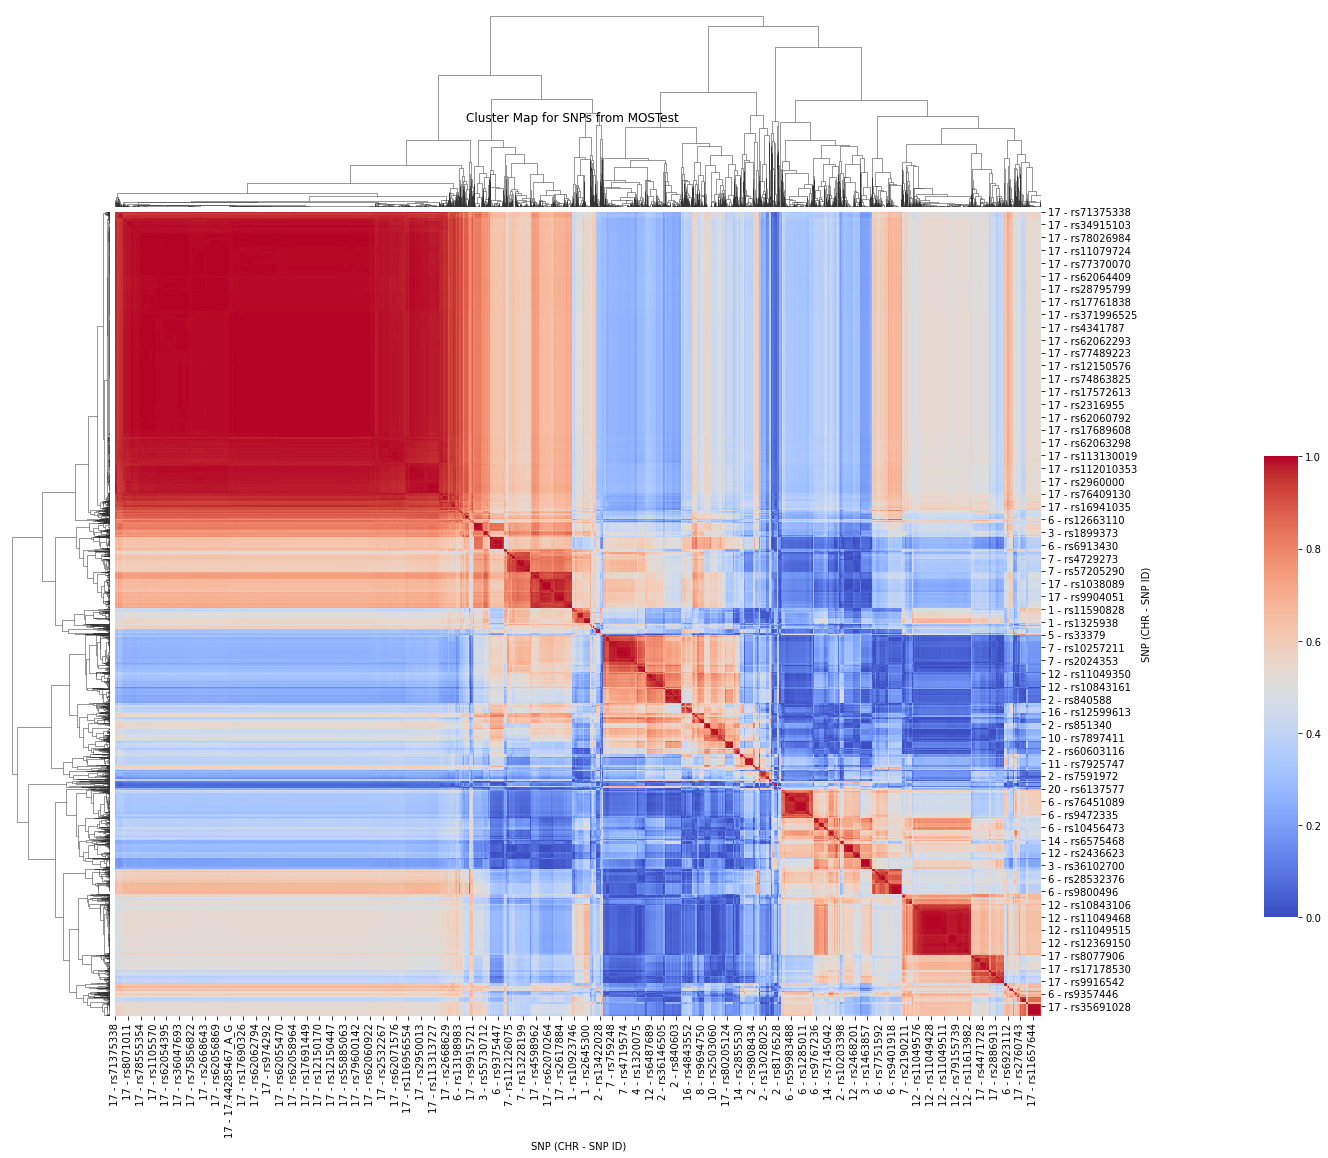

In [108]:
for z_score_file in file_paths:
    base_path_to_save = os.path.dirname(z_score_file)
    path_to_save = os.path.join(base_path_to_save, "nb_of_direction_heuristic.tsv")
    corr = get_corr(z_score_file, path_to_save)